<a href="https://colab.research.google.com/github/shoyebhossancse07/webprogramming_lab_task1/blob/main/Copy_of_LAB_TASK3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Iris dataset
wine = load_wine()
X = wine.data  # only features, ignore target
Y = wine.target  # target class

In [ ]:
df = pd.DataFrame(X, columns=wine.feature_names)


In [ ]:
print("features names: ")
print(wine.feature_names)
print("Target classes: ")
print(wine.target_names)
print("Basic statistics : ")
print(df.describe())


features names: 
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target classes: 
['class_0' 'class_1' 'class_2']
Basic statistics : 
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenol

In [ ]:
print("\nChecking Null Values:")
print( df.isnull().sum())
df= df.dropna()


Checking Null Values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


In [ ]:
# X = df.drop('target',axis=1)
# Y = df['target']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# 1. Initialize and Train
lr_classifier = LogisticRegression(random_state=42)
lr_classifier.fit(X_train_scaled, Y_train)

LogisticRegression(random_state=42)

In [ ]:
# 2. Predict
Y_pred = lr_classifier.predict(X_test_scaled)

In [ ]:
# 3. Evaluate
print("\nLogistic Regression Accuracy:", accuracy_score(Y_test, Y_pred))


Logistic Regression Accuracy: 1.0


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# 1. Initialize and Train (Choosing k=5 neighbors)
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train_scaled, Y_train)

KNeighborsClassifier()

In [ ]:
# 2. Predict
Y_pred = knn_classifier.predict(X_test_scaled)

In [ ]:
# 3. Evaluate
print("\nKNN Accuracy:", accuracy_score(Y_test, Y_pred))


KNN Accuracy: 0.9444444444444444


In [ ]:
from sklearn.svm import SVC

In [ ]:
# 1. Initialize and Train
svm_classifier = SVC(random_state=42)
svm_classifier.fit(X_train_scaled, Y_train)

SVC(random_state=42)

In [ ]:
# 2. Predict
Y_pred = svm_classifier.predict(X_test_scaled)

In [ ]:
# 3. Evaluate
print("\nSVM Accuracy:", accuracy_score(Y_test, Y_pred))


SVM Accuracy: 1.0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("\n" + "="*50)
print(" PART 1: CLASSIFICATION EVALUATION")
print("="*50)


 PART 1: CLASSIFICATION EVALUATION


In [ ]:
classifiers = {
    "1) Logistic Regression": LogisticRegression(random_state=42, max_iter=200),
    "2) K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
    "3) Support Vector Machine (SVM)": SVC(random_state=42),
    "4) Random Forest": RandomForestClassifier(random_state=42)
}

In [ ]:
for name, clf in classifiers.items():
    print(f"\n[{name}]")
    print("-" * 40)

    # 1. Train the classifier
    clf.fit(X_train_scaled, Y_train)

    # 2. Predict on test data
    Y_pred = clf.predict(X_test_scaled)

    # 3. Evaluate Classification
    accuracy = accuracy_score(Y_test, Y_pred)
    print(f"Accuracy: {accuracy:.4f} ({(accuracy*100):.2f}%)")

    print("\nConfusion Matrix:")
    print(confusion_matrix(Y_test, Y_pred))

    print("\nClassification Report:")
    print(classification_report(Y_test, Y_pred))
    print("=" * 50)


[1) Logistic Regression]
----------------------------------------
Accuracy: 1.0000 (100.00%)

Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


[2) K-Nearest Neighbors (KNN)]
----------------------------------------
Accuracy: 0.9444 (94.44%)

Confusion Matrix:
[[14  0  0]
 [ 1 12  1]
 [ 0  0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.86      0.92        14
           2       0.89      1.00      0.94         8

    accuracy                           0.94     

In [ ]:
# 1. Train the classifier
clf.fit(X_train_scaled, Y_train)

RandomForestClassifier(random_state=42)

In [ ]:
Y_pred = clf.predict(X_test_scaled)

In [ ]:
print("\nAccuracy Score:", accuracy_score(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))


Accuracy Score: 1.0

Confusion Matrix:
 [[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [ ]:
print("\n" + "="*40)
print(" PART 2: K-MEANS CLUSTERING")
print("="*40)


 PART 2: K-MEANS CLUSTERING


In [ ]:
X_scaled_full = scalar.fit_transform(X)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

In [ ]:
cluster_labels = kmeans.fit_predict(X_scaled_full)
print("Cluster assignment for first 10 samples:", cluster_labels[:10])

Cluster assignment for first 10 samples: [2 2 2 2 2 2 2 2 2 2]


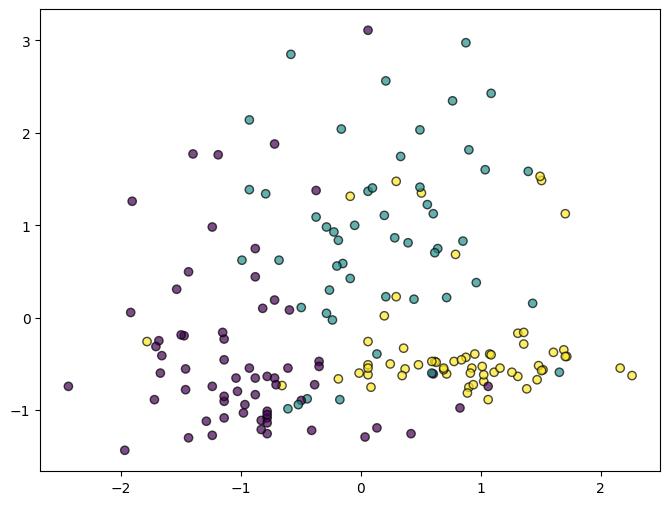

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled_full[:, 0], X_scaled_full[:, 1], c=cluster_labels, cmap='viridis', marker='o', edgecolor='k', alpha=0.7)

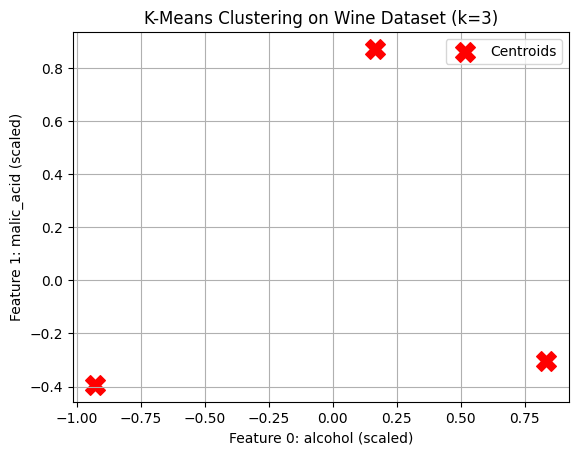

In [ ]:
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title('K-Means Clustering on Wine Dataset (k=3)')
plt.xlabel(f"Feature 0: {wine.feature_names[0]} (scaled)")
plt.ylabel(f"Feature 1: {wine.feature_names[1]} (scaled)")
plt.legend()
plt.grid(True)
plt.show()